In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [2]:
print("Current working directory:", os.getcwd())

# Build the absolute path based on your notebook's location
# (Assuming the notebook is in the same folder as 'data')
base_dir = os.getcwd()
train_path = os.path.join(base_dir, "data", "CICIOT23", "train", "train.csv")
test_path  = os.path.join(base_dir, "data", "CICIOT23", "test", "test.csv")
valid_path = os.path.join(base_dir, "data", "CICIOT23", "validation", "validation.csv")

print("\nChecking files:")
print(f"Train exists: {os.path.exists(train_path)}")
print(f"Test  exists: {os.path.exists(test_path)}")
print(f"Valid exists: {os.path.exists(valid_path)}")

Current working directory: d:\SAG-Internship-Project

Checking files:
Train exists: True
Test  exists: True
Valid exists: True


In [3]:
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)
validation_data = pd.read_csv(valid_path)
print("Data loaded successfully!")

Data loaded successfully!


# Analyse Training data

In [4]:
train_data.head(10)

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood
5,0.000000,0.00,1.00,64.00,42.556060,42.556060,0.0,0.0,0.0,0.0,...,0.000000,42.00,8.312470e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood
6,0.000000,0.00,1.00,64.00,2.183256,2.183256,0.0,0.0,0.0,0.0,...,0.000000,42.00,8.315031e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood
7,0.000000,54.00,6.00,64.00,1.883594,1.883594,0.0,0.0,0.0,0.0,...,0.000000,54.00,8.307231e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-TCP_Flood
8,0.000000,54.00,6.00,64.00,4.711073,4.711073,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309438e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
9,0.000000,0.00,1.00,64.00,4.686491,4.686491,0.0,0.0,0.0,0.0,...,0.000000,42.00,8.315005e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5491971 entries, 0 to 5491970
Data columns (total 47 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flow_duration    float64
 1   Header_Length    float64
 2   Protocol Type    float64
 3   Duration         float64
 4   Rate             float64
 5   Srate            float64
 6   Drate            float64
 7   fin_flag_number  float64
 8   syn_flag_number  float64
 9   rst_flag_number  float64
 10  psh_flag_number  float64
 11  ack_flag_number  float64
 12  ece_flag_number  float64
 13  cwr_flag_number  float64
 14  ack_count        float64
 15  syn_count        float64
 16  fin_count        float64
 17  urg_count        float64
 18  rst_count        float64
 19  HTTP             float64
 20  HTTPS            float64
 21  DNS              float64
 22  Telnet           float64
 23  SMTP             float64
 24  SSH              float64
 25  IRC              float64
 26  TCP              float64
 27  UDP         

In [6]:
train_data.describe()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,...,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06
mean,5.657345e+00,7.687147e+04,9.066457e+00,6.636141e+01,9.049942e+03,9.049942e+03,3.229612e-06,8.650082e-02,2.071142e-01,9.042418e-02,...,1.247361e+02,3.341244e+01,1.247348e+02,8.319404e+07,9.499002e+00,1.312450e+01,4.721960e+01,3.076685e+04,9.657527e-02,1.415261e+02
std,2.749157e+02,4.615005e+05,8.943837e+00,1.406518e+01,9.986400e+04,9.986400e+04,1.848825e-03,2.811022e-01,4.052381e-01,2.867885e-01,...,2.411282e+02,1.604832e+02,2.416016e+02,1.706512e+07,8.201925e-01,8.632303e+00,2.269779e+02,3.208097e+05,2.332437e-01,2.109219e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.200000e+01,0.000000e+00,4.200000e+01,0.000000e+00,1.000000e+00,9.165151e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,2.093860e+00,2.093860e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.000000e+01,0.000000e+00,5.000000e+01,8.307157e+07,9.500000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
50%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,1.578598e+01,1.578598e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.400000e+01,0.000000e+00,5.400000e+01,8.312452e+07,9.500000e+00,1.039230e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
75%,1.050286e-01,3.001300e+02,1.444000e+01,6.400000e+01,1.178755e+02,1.178755e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.405011e+01,3.719096e-01,5.406000e+01,8.334391e+07,9.500000e+00,1.039671e+01,5.059213e-01,1.344216e+00,8.000000e-02,1.415500e+02
max,9.943576e+04,9.890105e+06,4.700000e+01,2.550000e+02,8.388608e+06,8.388608e+06,2.679210e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.160047e+04,9.302373e+03,1.309800e+04,1.676394e+08,1.500000e+01,1.453904e+02,1.315554e+04,9.670837e+07,1.000000e+00,2.446000e+02


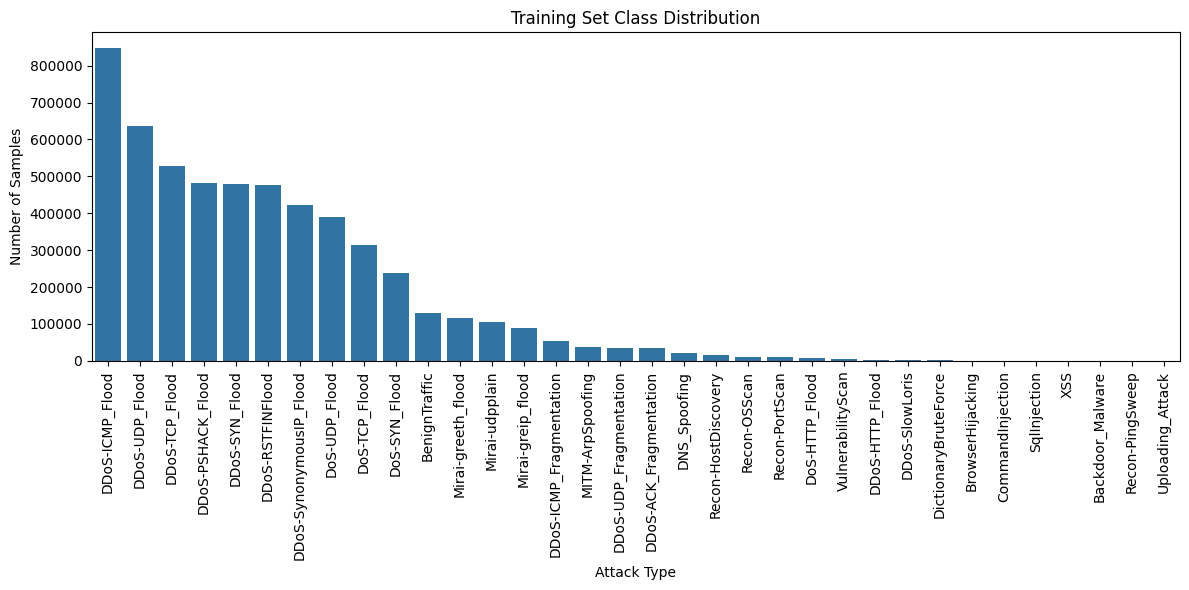

In [7]:
plt.figure(figsize=(12,6))
class_counts = train_data['label'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=90)
plt.title('Training Set Class Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

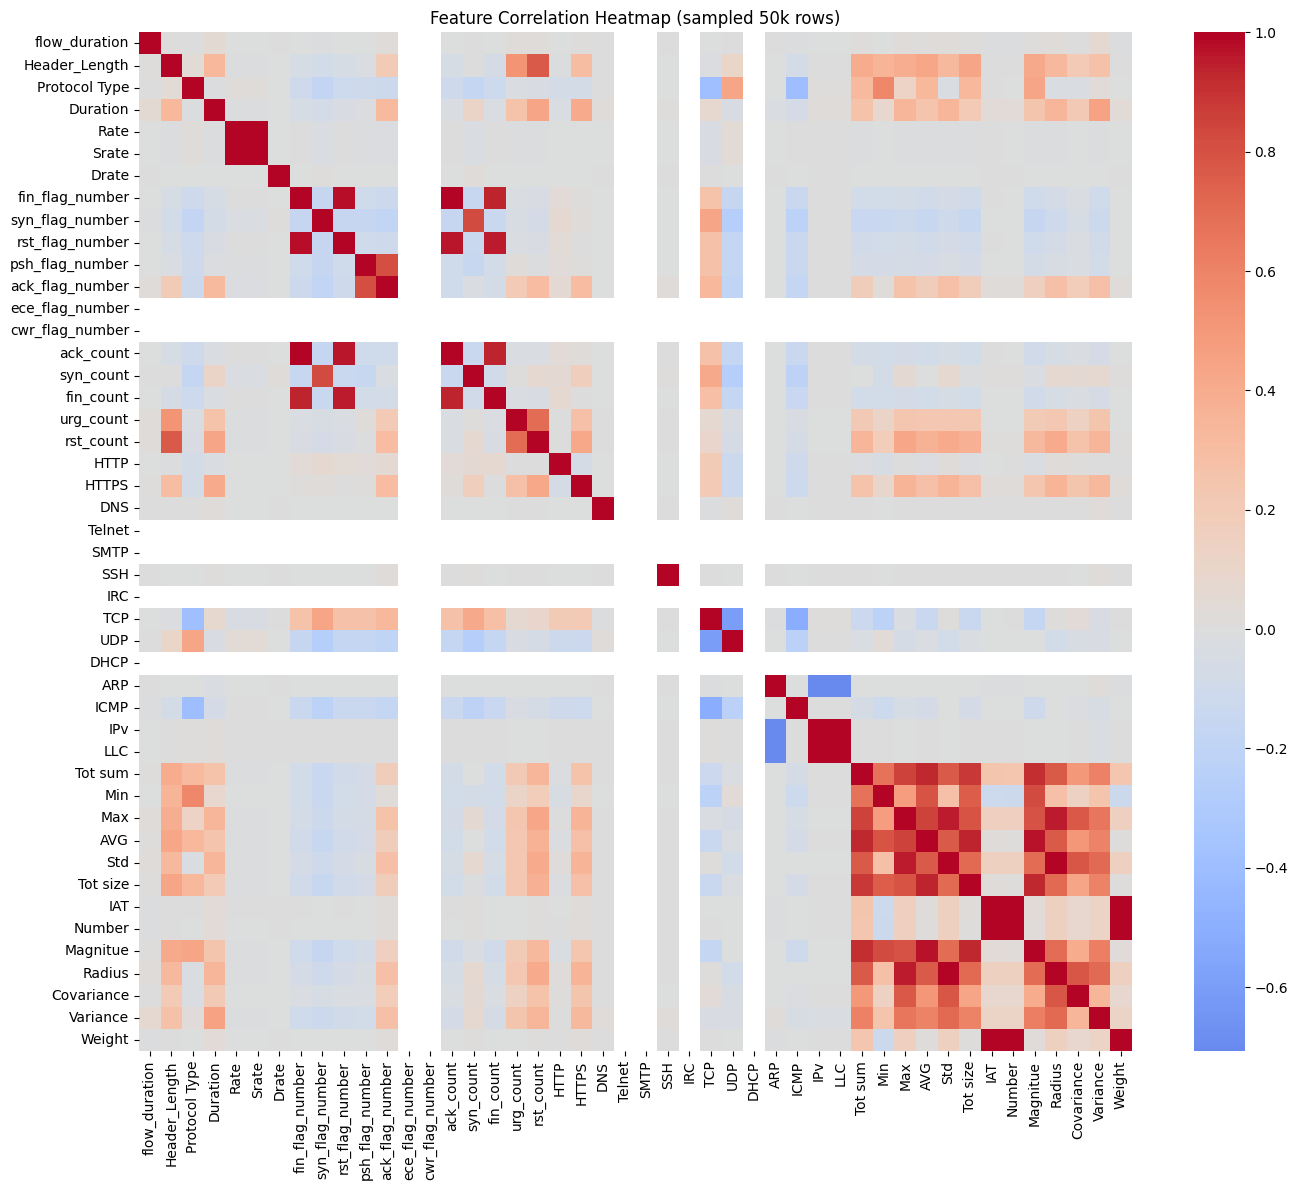

In [8]:
sample_df = train_data.sample(n=50000, random_state=42)

# Select only numeric columns (exclude label)
numeric_cols = sample_df.select_dtypes(include='number').columns.tolist()
# Remove some constant or near-constant columns if any, else keep all
corr = sample_df[numeric_cols].corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap (sampled 50k rows)')
plt.tight_layout()
plt.show()

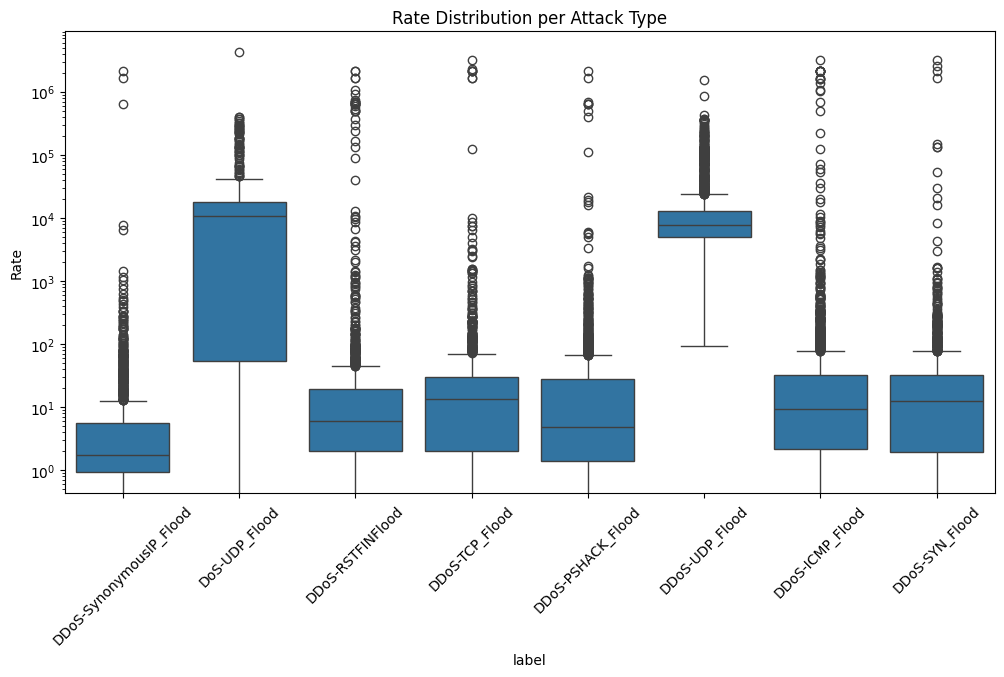

In [9]:
sampled = train_data.sample(n=20000, random_state=42)
top_classes = sampled['label'].value_counts().nlargest(8).index  # Top 8 classes
filtered = sampled[sampled['label'].isin(top_classes)]

plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='Rate', data=filtered)
plt.xticks(rotation=45)
plt.title('Rate Distribution per Attack Type')
plt.yscale('log')  # Rate has wide range
plt.show()

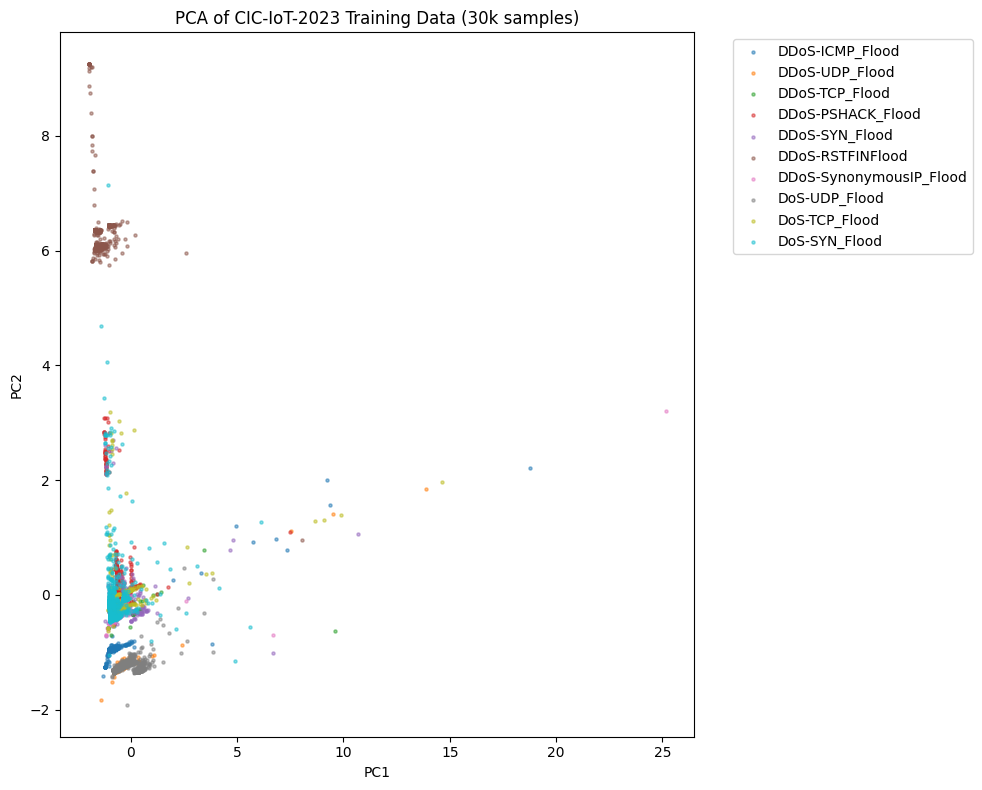

In [10]:
pca_sample = train_data.sample(n=30000, random_state=42)
X = pca_sample.drop('label', axis=1).select_dtypes('number')
y = pca_sample['label']

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,8))
# Color by label, but too many labels; select top
top_labels = y.value_counts().nlargest(10).index
for label in top_labels:
    idx = y == label
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=label, alpha=0.5, s=5)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title('PCA of CIC-IoT-2023 Training Data (30k samples)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

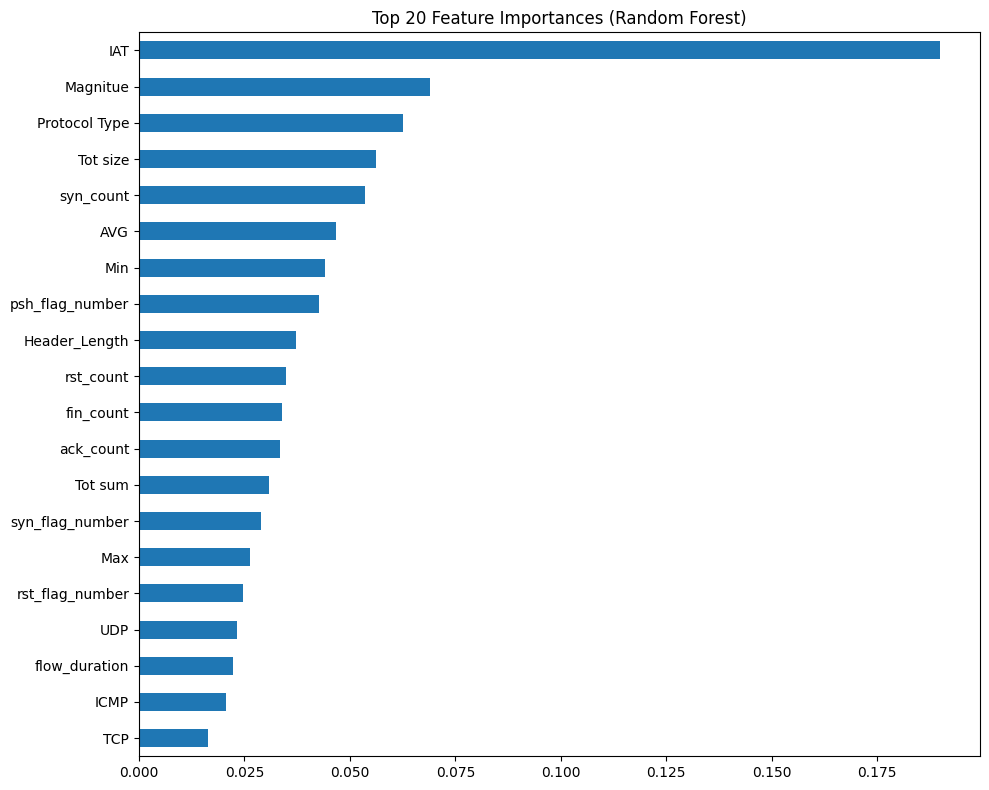

In [11]:
sample_size = 100000  # adjust as per your RAM
if len(train_data) > sample_size:
    df_sample = train_data.sample(sample_size, random_state=42)
else:
    df_sample = train_data.copy()

X_rf = df_sample.drop('label', axis=1).select_dtypes('number')
y_rf = df_sample['label']
le = LabelEncoder()
y_rf_enc = le.fit_transform(y_rf)

rf = RandomForestClassifier(n_estimators=20, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_rf, y_rf_enc)

# Plot top 20 features
importances = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importances.head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

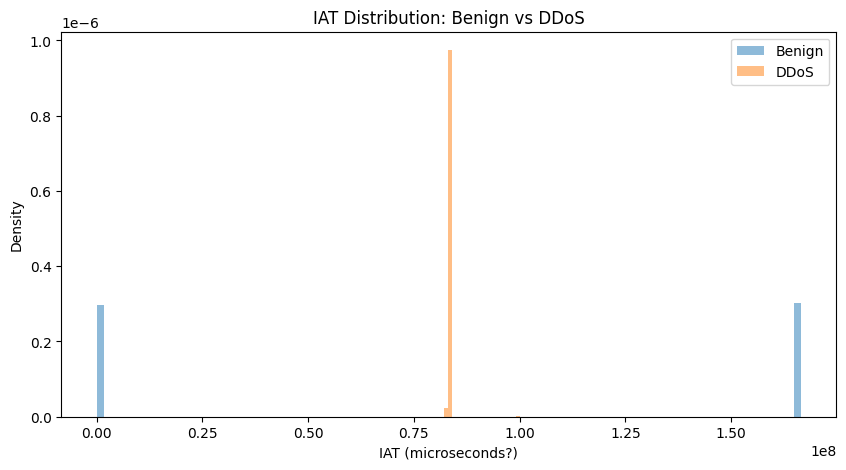

In [12]:
benign = train_data[train_data['label']=='BenignTraffic']
ddos = train_data[train_data['label'].str.contains('DDoS', na=False)]
# take samples
plt.figure(figsize=(10,5))
plt.hist(benign['IAT'].sample(20000), bins=100, alpha=0.5, label='Benign', density=True)
plt.hist(ddos['IAT'].sample(20000), bins=100, alpha=0.5, label='DDoS', density=True)
plt.legend()
plt.title('IAT Distribution: Benign vs DDoS')
plt.xlabel('IAT (microseconds?)')
plt.ylabel('Density')
plt.show()

# Analyse Test data

In [13]:
test_data.head(10)

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,5.018181,125.82,6.00,64.00,0.471037,0.471037,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.336227e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood
1,0.000000,0.00,47.00,64.00,4.992473,4.992473,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.367746e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
2,0.000000,55.22,6.05,65.27,31.735421,31.735421,0.0,0.0,0.0,0.0,...,0.776120,55.82,8.306829e+07,9.5,10.409427,1.111579,30.890194,0.02,141.55,DDoS-TCP_Flood
3,0.008299,5213.00,17.00,64.00,19365.300906,19365.300906,0.0,0.0,0.0,0.0,...,0.000000,50.00,8.310303e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DDoS-UDP_Flood
4,4.672666,108.00,6.00,64.00,0.428021,0.428021,0.0,0.0,0.0,0.0,...,0.000000,54.00,8.295115e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-TCP_Flood
5,18.205372,436.24,6.00,64.00,0.367177,0.367177,0.0,0.0,1.0,0.0,...,0.000000,74.00,8.300283e+07,9.5,12.165525,0.000000,0.000000,0.00,141.55,DoS-HTTP_Flood
6,0.000000,54.00,6.00,64.00,16.723433,16.723433,0.0,0.0,0.0,0.0,...,0.000000,54.00,8.331399e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-PSHACK_Flood
7,0.000000,54.75,6.11,64.64,0.998880,0.998880,0.0,0.0,0.0,0.0,...,2.572474,54.75,8.306738e+07,9.5,10.463018,3.643704,51.911877,0.13,141.55,DDoS-TCP_Flood
8,0.013611,57.15,6.00,63.78,26.667616,26.667616,0.0,1.0,0.0,1.0,...,0.791885,54.69,8.334390e+07,9.5,10.410710,1.125116,12.671363,0.05,141.55,DDoS-RSTFINFlood
9,0.000000,0.00,1.00,64.00,5.498413,5.498413,0.0,0.0,0.0,0.0,...,0.000000,42.00,8.313214e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood


In [14]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176851 entries, 0 to 1176850
Data columns (total 47 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   flow_duration    1176851 non-null  float64
 1   Header_Length    1176851 non-null  float64
 2   Protocol Type    1176851 non-null  float64
 3   Duration         1176851 non-null  float64
 4   Rate             1176851 non-null  float64
 5   Srate            1176851 non-null  float64
 6   Drate            1176851 non-null  float64
 7   fin_flag_number  1176851 non-null  float64
 8   syn_flag_number  1176851 non-null  float64
 9   rst_flag_number  1176851 non-null  float64
 10  psh_flag_number  1176851 non-null  float64
 11  ack_flag_number  1176851 non-null  float64
 12  ece_flag_number  1176851 non-null  float64
 13  cwr_flag_number  1176851 non-null  float64
 14  ack_count        1176851 non-null  float64
 15  syn_count        1176851 non-null  float64
 16  fin_count        1

In [15]:
test_data.describe()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,...,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06
mean,5.624726e+00,7.649345e+04,9.081084e+00,6.637249e+01,9.120311e+03,9.120311e+03,1.143707e-06,8.645869e-02,2.069914e-01,9.045580e-02,...,1.251847e+02,3.353654e+01,1.251712e+02,8.317806e+07,9.498286e+00,1.313944e+01,4.739039e+01,3.098332e+04,9.675934e-02,1.415069e+02
std,2.489151e+02,4.598023e+05,8.957816e+00,1.408322e+01,1.006035e+05,1.006035e+05,2.528345e-04,2.810403e-01,4.051495e-01,2.868338e-01,...,2.427747e+02,1.609270e+02,2.428775e+02,1.705375e+07,8.193874e-01,8.659925e+00,2.275948e+02,3.274598e+05,2.333406e-01,2.107716e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.200000e+01,0.000000e+00,4.200000e+01,0.000000e+00,1.000000e+00,9.165151e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,2.098258e+00,2.098258e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.000000e+01,0.000000e+00,5.000000e+01,8.307156e+07,9.500000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
50%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,1.586798e+01,1.586798e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.400000e+01,0.000000e+00,5.400000e+01,8.312452e+07,9.500000e+00,1.039230e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
75%,1.050476e-01,3.044350e+02,1.460000e+01,6.400000e+01,1.191760e+02,1.191760e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.405258e+01,3.809714e-01,5.406000e+01,8.334391e+07,9.500000e+00,1.039675e+01,5.094656e-01,1.448118e+00,8.000000e-02,1.415500e+02
max,5.947517e+04,9.815845e+06,4.700000e+01,2.550000e+02,8.388608e+06,8.388608e+06,1.430061e-01,1.000000e+00,1.000000e+00,1.000000e+00,...,9.231150e+03,8.290916e+03,6.582000e+03,1.676394e+08,1.500000e+01,1.318266e+02,1.172513e+04,7.713750e+07,1.000000e+00,2.446000e+02


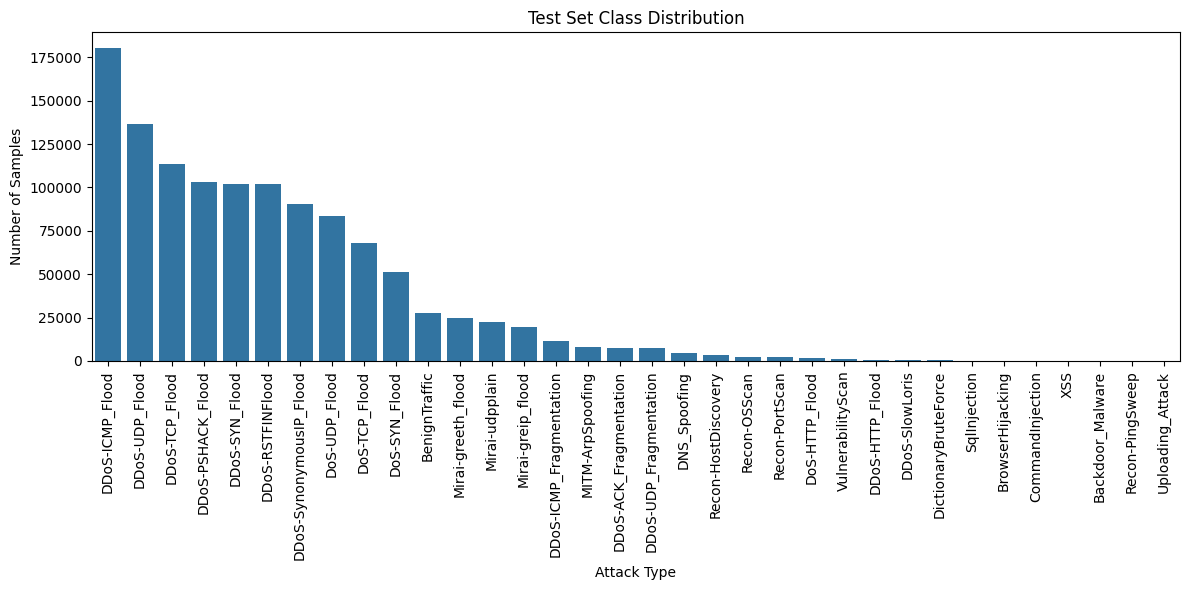

In [16]:
plt.figure(figsize=(12,6))
class_counts = test_data['label'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=90)
plt.title('Test Set Class Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

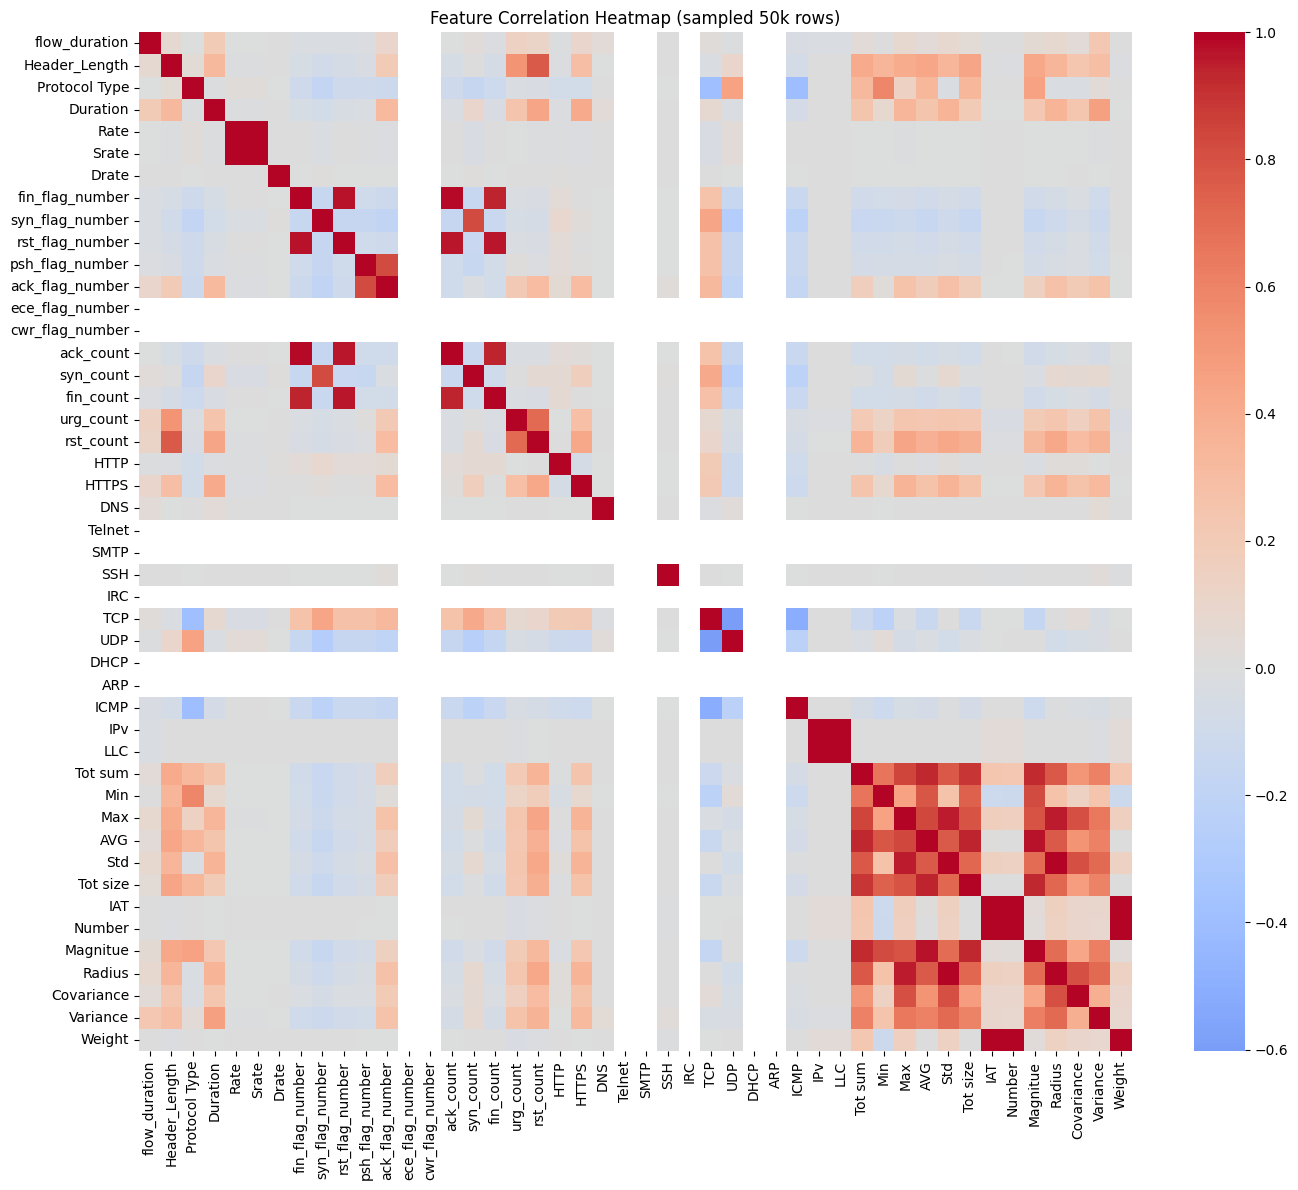

In [17]:
sample_df = test_data.sample(n=50000, random_state=42)

# Select only numeric columns (exclude label)
numeric_cols = sample_df.select_dtypes(include='number').columns.tolist()
# Remove some constant or near-constant columns if any, else keep all
corr = sample_df[numeric_cols].corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap (sampled 50k rows)')
plt.tight_layout()
plt.show()

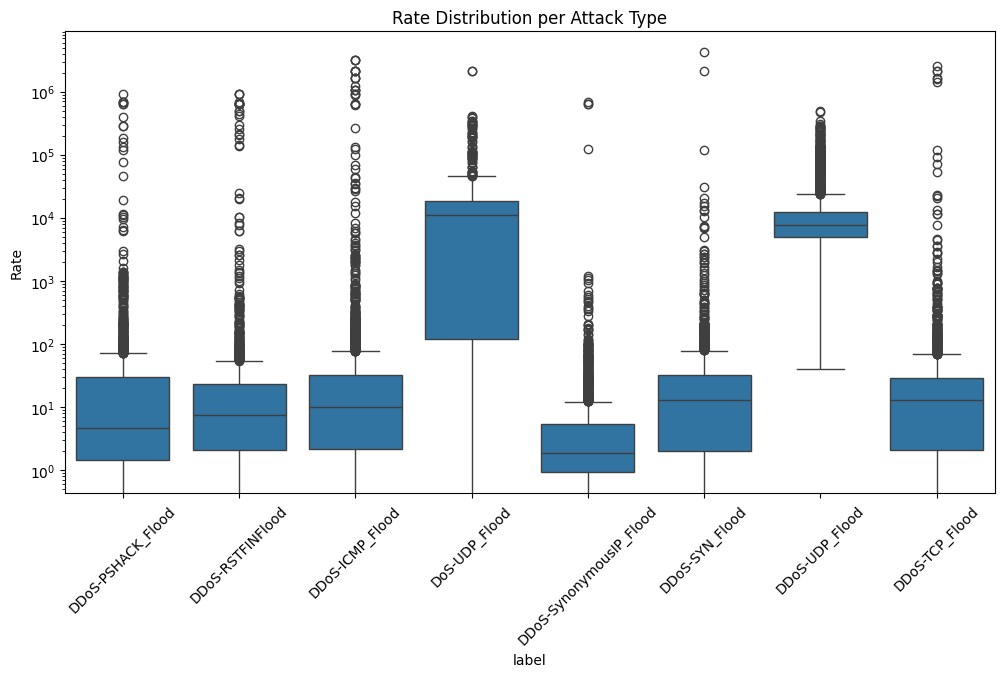

In [18]:
sampled = test_data.sample(n=20000, random_state=42)
top_classes = sampled['label'].value_counts().nlargest(8).index  # Top 8 classes
filtered = sampled[sampled['label'].isin(top_classes)]
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='Rate', data=filtered)
plt.xticks(rotation=45)
plt.title('Rate Distribution per Attack Type')
plt.yscale('log')  # Rate has wide range
plt.show()

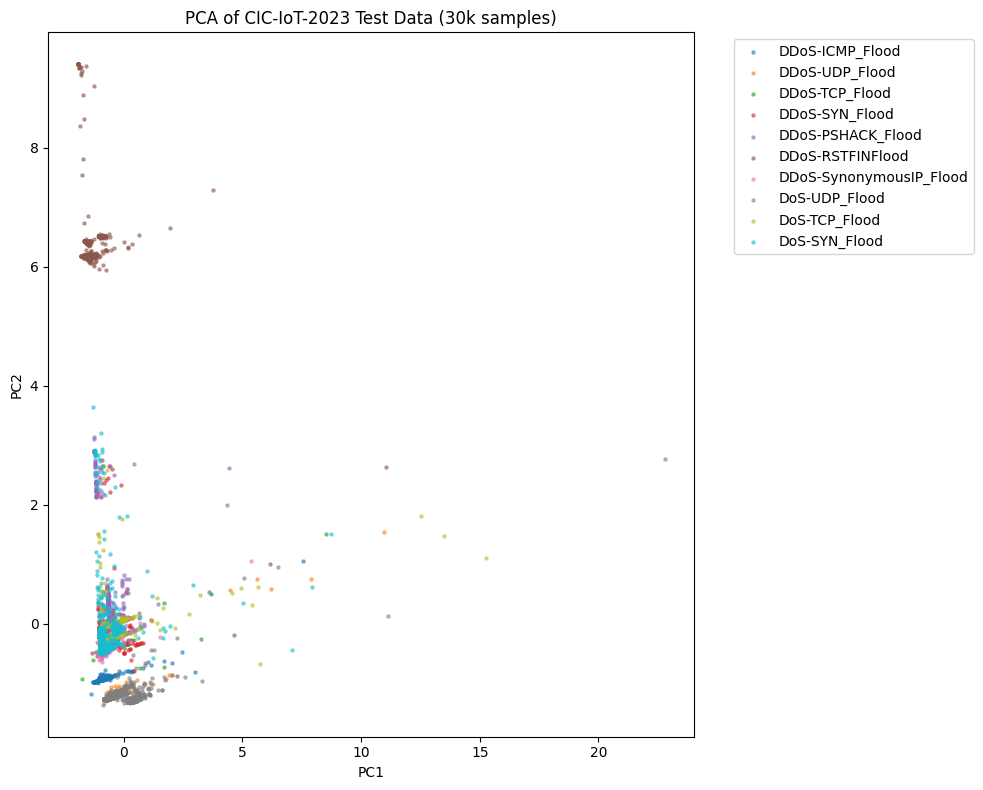

In [19]:
pca_sample = test_data.sample(n=30000, random_state=42)
X = pca_sample.drop('label', axis=1).select_dtypes('number')
y = pca_sample['label']

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,8))
# Color by label, but too many labels; select top
top_labels = y.value_counts().nlargest(10).index
for label in top_labels:
    idx = y == label
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=label, alpha=0.5, s=5)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title('PCA of CIC-IoT-2023 Test Data (30k samples)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

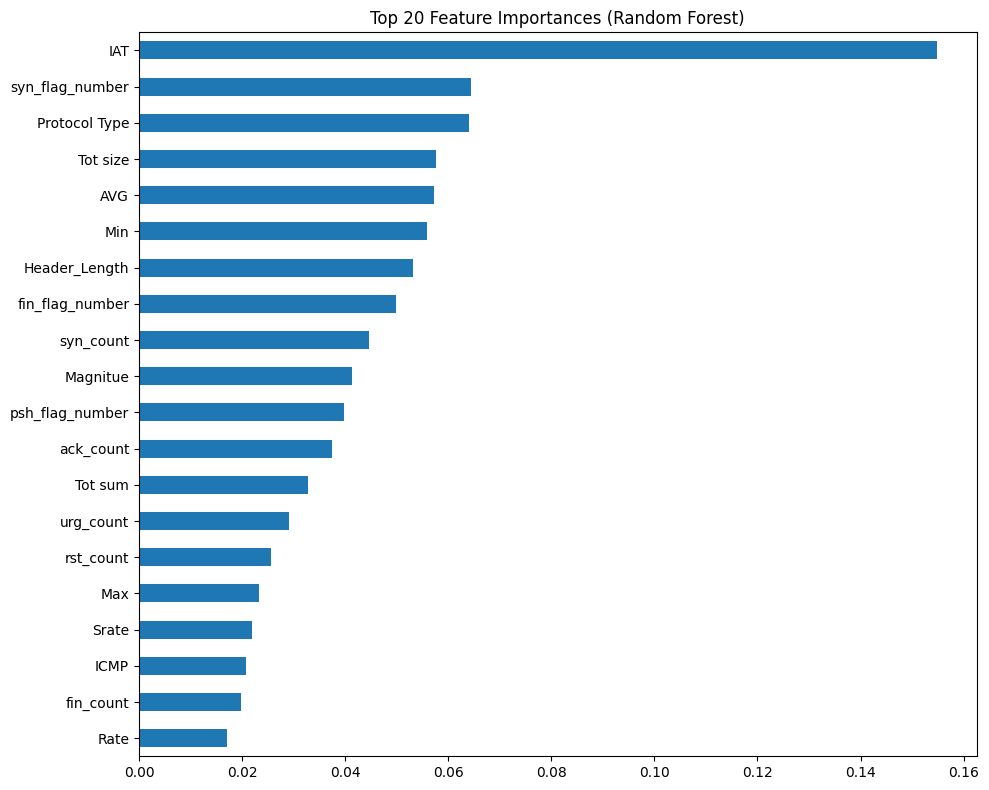

In [20]:
sample_size = 100000  # adjust as per your RAM
if len(test_data) > sample_size:
    df_sample = test_data.sample(sample_size, random_state=42)
else:
    df_sample = test_data.copy()

X_rf = df_sample.drop('label', axis=1).select_dtypes('number')
y_rf = df_sample['label']
le = LabelEncoder()
y_rf_enc = le.fit_transform(y_rf)

rf = RandomForestClassifier(n_estimators=20, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_rf, y_rf_enc)

# Plot top 20 features
importances = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importances.head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

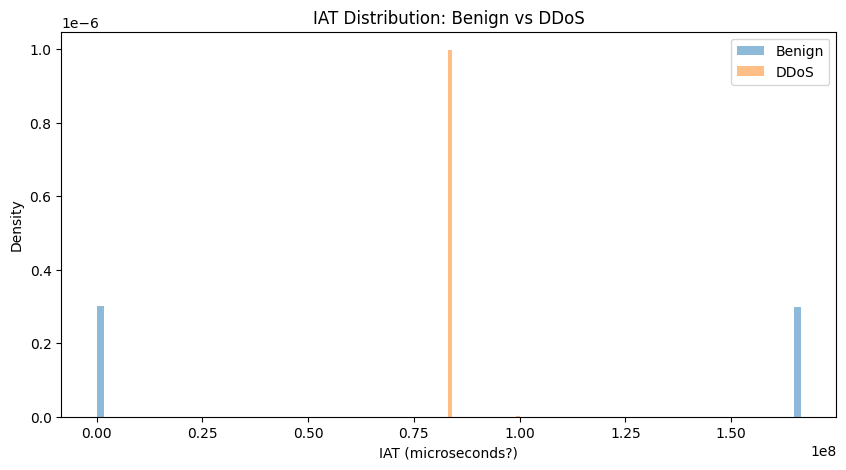

In [21]:
benign = test_data[test_data['label']=='BenignTraffic']
ddos = test_data[test_data['label'].str.contains('DDoS', na=False)]
# take samples
plt.figure(figsize=(10,5))
plt.hist(benign['IAT'].sample(20000), bins=100, alpha=0.5, label='Benign', density=True)
plt.hist(ddos['IAT'].sample(20000), bins=100, alpha=0.5, label='DDoS', density=True)
plt.legend()
plt.title('IAT Distribution: Benign vs DDoS')
plt.xlabel('IAT (microseconds?)')
plt.ylabel('Density')
plt.show()

# Analyse Validation Data

In [22]:
validation_data.head(10)

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,53.46,5.94,63.36,3.917327,3.917327,0.0,0.0,0.0,0.0,...,0.131850,54.06,8.303407e+07,9.5,10.395650,0.186918,0.195153,0.09,141.55,DDoS-TCP_Flood
1,0.000000,54.00,6.00,64.00,18.522314,18.522314,0.0,0.0,0.0,0.0,...,0.000000,54.00,8.307611e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-TCP_Flood
2,0.000000,0.00,0.98,62.72,26.927732,26.927732,0.0,0.0,0.0,0.0,...,0.328233,42.36,8.312778e+07,9.5,9.177402,0.465945,1.822612,0.06,141.55,DDoS-ICMP_Flood
3,0.004975,60.56,6.00,64.00,1.927037,1.927037,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309408e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
4,53.269357,2345336.20,6.00,62.80,56.269610,56.269610,0.0,0.0,0.0,0.0,...,690.377137,1518.00,4.900789e-03,5.5,48.235028,976.340710,538215.316599,0.90,38.50,BenignTraffic
5,0.000000,54.00,6.00,64.00,24.402158,24.402158,0.0,0.0,0.0,0.0,...,0.000000,54.00,8.307617e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-TCP_Flood
6,0.000000,54.04,6.00,65.91,40.771406,40.771406,0.0,0.0,1.0,0.0,...,0.111399,54.04,8.298561e+07,9.5,10.395270,0.157845,0.114358,0.11,141.55,DoS-SYN_Flood
7,0.000000,0.00,1.00,64.00,378.564376,378.564376,0.0,0.0,0.0,0.0,...,0.000000,42.00,8.315004e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood
8,0.000000,54.00,6.00,64.00,0.399034,0.399034,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.308930e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
9,0.000000,0.00,1.00,64.00,0.760170,0.760170,0.0,0.0,0.0,0.0,...,0.000000,42.00,8.312405e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood


In [23]:
validation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176851 entries, 0 to 1176850
Data columns (total 47 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   flow_duration    1176851 non-null  float64
 1   Header_Length    1176851 non-null  float64
 2   Protocol Type    1176851 non-null  float64
 3   Duration         1176851 non-null  float64
 4   Rate             1176851 non-null  float64
 5   Srate            1176851 non-null  float64
 6   Drate            1176851 non-null  float64
 7   fin_flag_number  1176851 non-null  float64
 8   syn_flag_number  1176851 non-null  float64
 9   rst_flag_number  1176851 non-null  float64
 10  psh_flag_number  1176851 non-null  float64
 11  ack_flag_number  1176851 non-null  float64
 12  ece_flag_number  1176851 non-null  float64
 13  cwr_flag_number  1176851 non-null  float64
 14  ack_count        1176851 non-null  float64
 15  syn_count        1176851 non-null  float64
 16  fin_count        1

In [24]:
validation_data.describe()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,...,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06,1.176851e+06
mean,5.872344e+00,7.672027e+04,9.055796e+00,6.635348e+01,9.092849e+03,9.092849e+03,2.570697e-05,8.623182e-02,2.077051e-01,9.017794e-02,...,1.246135e+02,3.338193e+01,1.245683e+02,8.318252e+07,9.498498e+00,1.311738e+01,4.717631e+01,3.104272e+04,9.646581e-02,1.415134e+02
std,2.802396e+02,4.627225e+05,8.936240e+00,1.405691e+01,1.004311e+05,1.004311e+05,2.586738e-02,2.807062e-01,4.056647e-01,2.864366e-01,...,2.416436e+02,1.610651e+02,2.415461e+02,1.704969e+07,8.196053e-01,8.628046e+00,2.278019e+02,3.481584e+05,2.329437e-01,2.107291e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.200000e+01,0.000000e+00,4.200000e+01,0.000000e+00,1.000000e+00,9.165151e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,2.088545e+00,2.088545e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.000000e+01,0.000000e+00,5.000000e+01,8.307157e+07,9.500000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
50%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,1.572735e+01,1.572735e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.400000e+01,0.000000e+00,5.400000e+01,8.312452e+07,9.500000e+00,1.039230e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
75%,1.043707e-01,2.708400e+02,1.420000e+01,6.400000e+01,1.164349e+02,1.164349e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.404613e+01,3.750172e-01,5.406000e+01,8.334390e+07,9.500000e+00,1.039651e+01,5.059213e-01,1.355839e+00,8.000000e-02,1.415500e+02
max,6.572927e+04,9.905298e+06,4.700000e+01,2.550000e+02,8.388608e+06,8.388608e+06,2.805555e+01,1.000000e+00,1.000000e+00,1.000000e+00,...,8.566760e+03,1.099626e+04,5.858000e+03,1.676394e+08,1.500000e+01,1.255973e+02,1.555106e+04,1.372844e+08,1.000000e+00,2.446000e+02


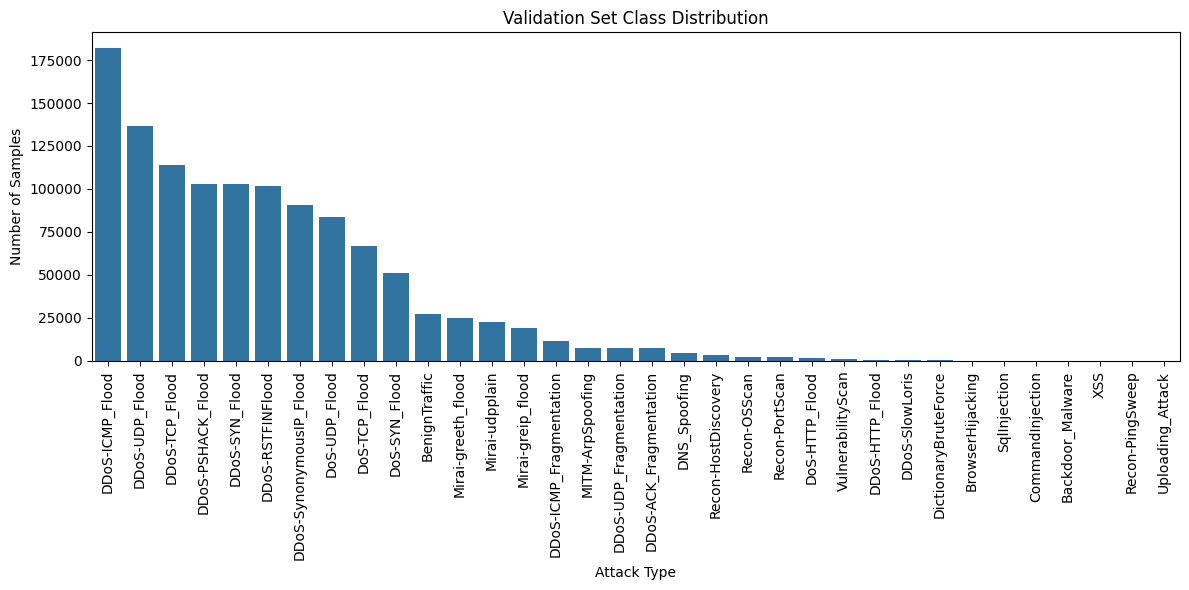

In [25]:
plt.figure(figsize=(12,6))
class_counts = validation_data['label'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(rotation=90)
plt.title('Validation Set Class Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

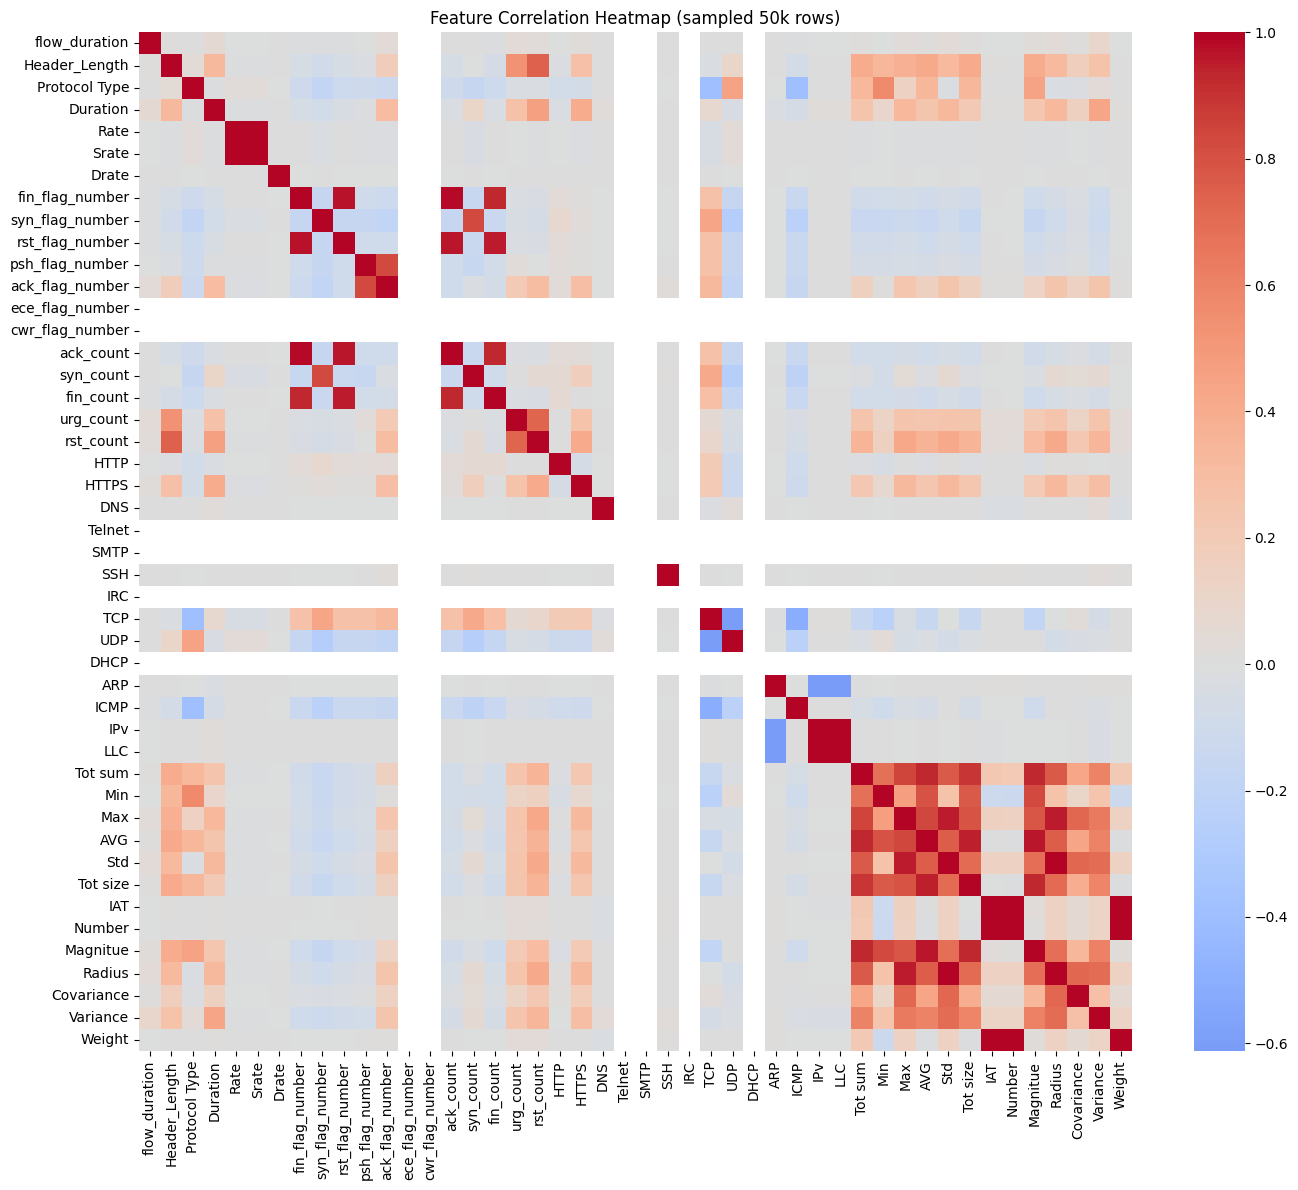

In [26]:
sample_df = validation_data.sample(n=50000, random_state=42)

# Select only numeric columns (exclude label)
numeric_cols = sample_df.select_dtypes(include='number').columns.tolist()
# Remove some constant or near-constant columns if any, else keep all
corr = sample_df[numeric_cols].corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap (sampled 50k rows)')
plt.tight_layout()
plt.show()

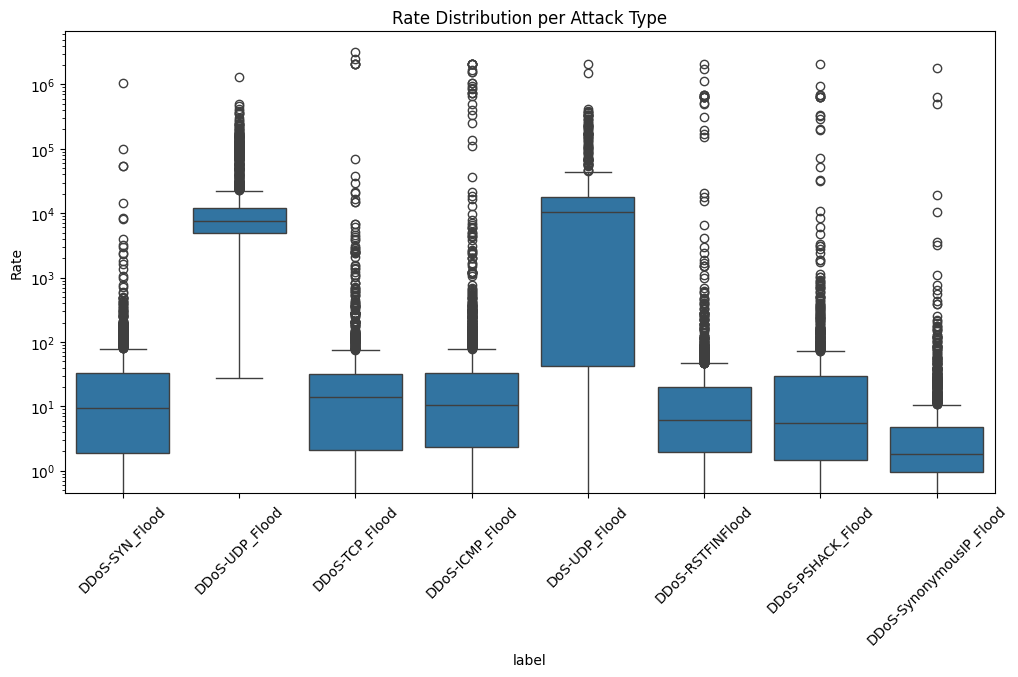

In [27]:
sampled = validation_data.sample(n=20000, random_state=42)
top_classes = sampled['label'].value_counts().nlargest(8).index  # Top 8 classes
filtered = sampled[sampled['label'].isin(top_classes)]
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='Rate', data=filtered)
plt.xticks(rotation=45)
plt.title('Rate Distribution per Attack Type')
plt.yscale('log')  # Rate has wide range
plt.show()

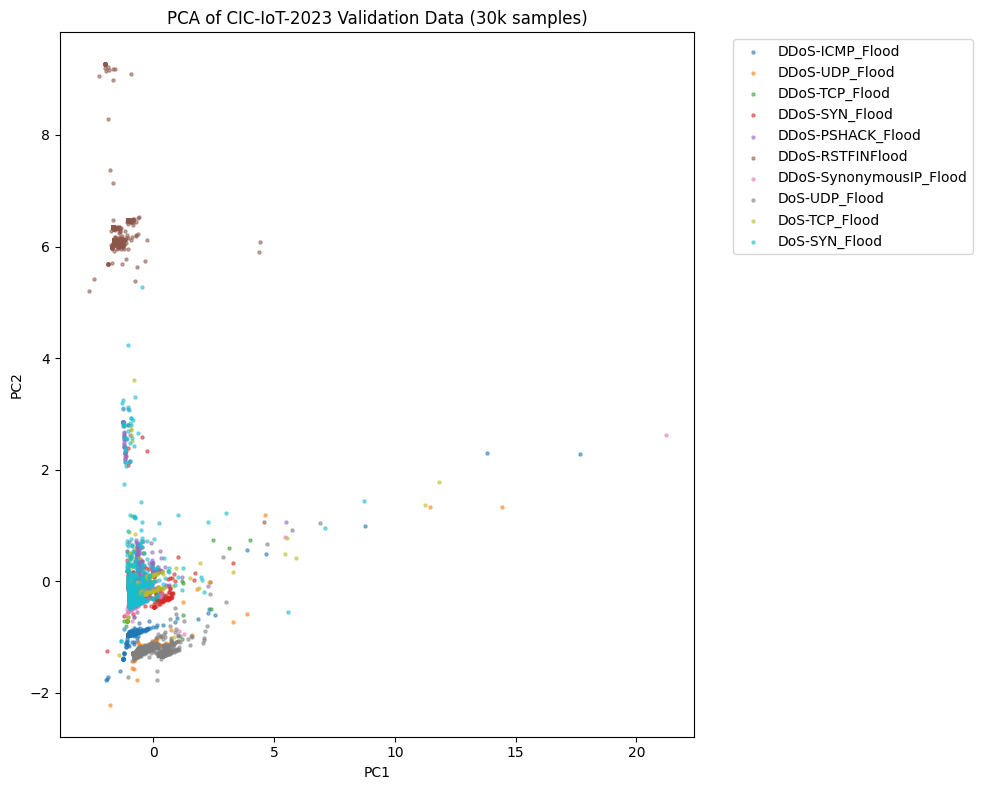

In [28]:
pca_sample = validation_data.sample(n=30000, random_state=42)
X = pca_sample.drop('label', axis=1).select_dtypes('number')
y = pca_sample['label']

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,8))
# Color by label, but too many labels; select top
top_labels = y.value_counts().nlargest(10).index
for label in top_labels:
    idx = y == label
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=label, alpha=0.5, s=5)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title('PCA of CIC-IoT-2023 Validation Data (30k samples)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

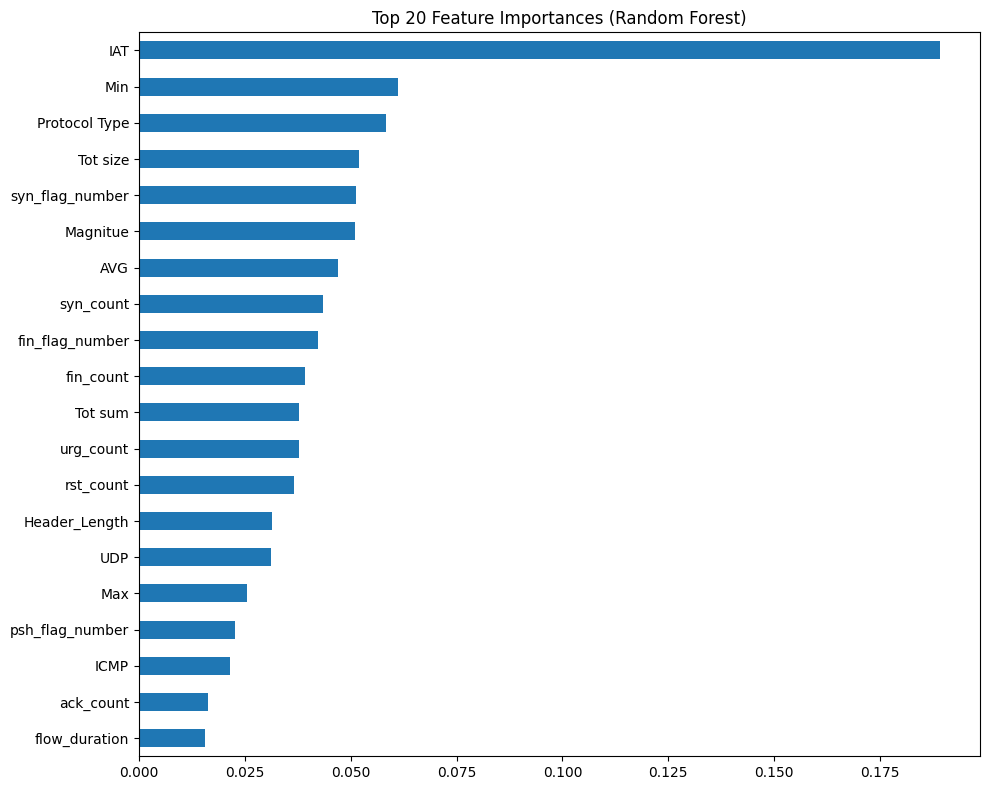

In [29]:
sample_size = 100000  # adjust as per your RAM
if len(validation_data) > sample_size:
    df_sample = validation_data.sample(sample_size, random_state=42)
else:
    df_sample = validation_data.copy()

X_rf = df_sample.drop('label', axis=1).select_dtypes('number')
y_rf = df_sample['label']
le = LabelEncoder()
y_rf_enc = le.fit_transform(y_rf)

rf = RandomForestClassifier(n_estimators=20, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_rf, y_rf_enc)

# Plot top 20 features
importances = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
plt.figure(figsize=(10,8))
importances.head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

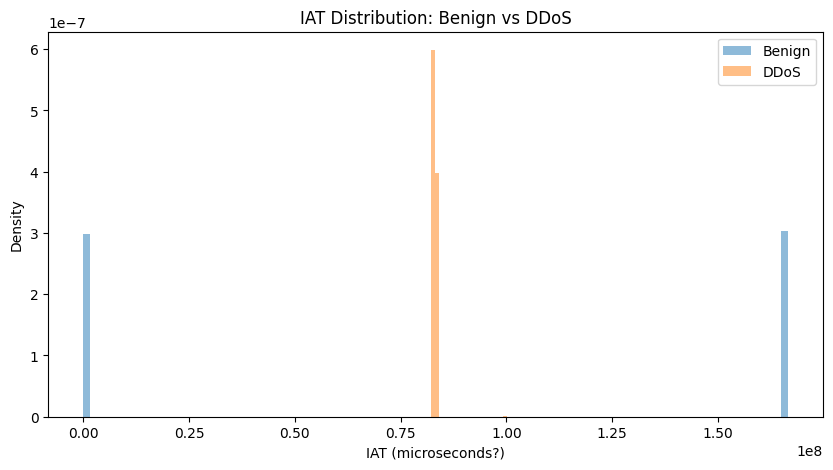

In [30]:
benign = validation_data[validation_data['label']=='BenignTraffic']
ddos = validation_data[validation_data['label'].str.contains('DDoS', na=False)]
# take samples
plt.figure(figsize=(10,5))
plt.hist(benign['IAT'].sample(20000), bins=100, alpha=0.5, label='Benign', density=True)
plt.hist(ddos['IAT'].sample(20000), bins=100, alpha=0.5, label='DDoS', density=True)
plt.legend()
plt.title('IAT Distribution: Benign vs DDoS')
plt.xlabel('IAT (microseconds?)')
plt.ylabel('Density')
plt.show()